In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
data224 = pd.read_csv('/content/33100224.csv')
df_tbill = pd.read_csv('/content/tbill_all.csv')
df_bond = pd.read_csv('/content/bond_yields.csv')

In [ ]:
data224.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6986 entries, 0 to 6985
Data columns (total 16 columns):
 #   Column                                                                    Non-Null Count  Dtype  
---  ------                                                                    --------------  -----  
 0   REF_DATE                                                                  6986 non-null   object 
 1   GEO                                                                       6986 non-null   object 
 2   DGUID                                                                     6986 non-null   object 
 3   North American Industry Classification System (NAICS)                     6986 non-null   object 
 4   Balance sheet and income statement components, selected financial ratios  6986 non-null   object 
 5   UOM                                                                       6986 non-null   object 
 6   UOM_ID                                                          

In [ ]:
df224 = data224.iloc[:, :12].copy()

In [ ]:
df224.head()

,REF_DATE,GEO,DGUID,North American Industry Classification System (NAICS),"Balance sheet and income statement components, selected financial ratios",UOM,UOM_ID,SCALAR_FACTOR,SCALAR_ID,VECTOR,COORDINATE,VALUE
0,2010-01,Canada,2016A000011124,"Total, all industries",Total assets,Dollars,81,millions,6,v1145999133,1.1.1,6792668.0
1,2010-01,Canada,2016A000011124,"Total, all industries",Cash and deposits,Dollars,81,millions,6,v1145999134,1.1.2,398412.0
2,2010-01,Canada,2016A000011124,"Total, all industries",Cash and deposits in Canadian currency,Dollars,81,millions,6,v1145999135,1.1.3,421468.0
3,2010-01,Canada,2016A000011124,"Total, all industries",Cash and deposits in foreign currency,Dollars,81,millions,6,v1145999136,1.1.4,83623.0
4,2010-01,Canada,2016A000011124,"Total, all industries",Accounts receivable,Dollars,81,millions,6,v1145999137,1.1.5,68294.0


Since main value is the value column, to make the analysis precise, data will be cleaned. for the data frame 33100224,

In [ ]:
df224.dropna(subset=['VALUE'], inplace=True)

In [ ]:
df224.info()


<class 'pandas.core.frame.DataFrame'>
Index: 2092 entries, 0 to 6980
Data columns (total 12 columns):
 #   Column                                                                    Non-Null Count  Dtype  
---  ------                                                                    --------------  -----  
 0   REF_DATE                                                                  2092 non-null   object 
 1   GEO                                                                       2092 non-null   object 
 2   DGUID                                                                     2092 non-null   object 
 3   North American Industry Classification System (NAICS)                     2092 non-null   object 
 4   Balance sheet and income statement components, selected financial ratios  2092 non-null   object 
 5   UOM                                                                       2092 non-null   object 
 6   UOM_ID                                                               

In [ ]:
df224.head()

,REF_DATE,GEO,DGUID,North American Industry Classification System (NAICS),"Balance sheet and income statement components, selected financial ratios",UOM,UOM_ID,SCALAR_FACTOR,SCALAR_ID,VECTOR,COORDINATE,VALUE
0,2010-01,Canada,2016A000011124,"Total, all industries",Total assets,Dollars,81,millions,6,v1145999133,1.1.1,6792668.0
1,2010-01,Canada,2016A000011124,"Total, all industries",Cash and deposits,Dollars,81,millions,6,v1145999134,1.1.2,398412.0
2,2010-01,Canada,2016A000011124,"Total, all industries",Cash and deposits in Canadian currency,Dollars,81,millions,6,v1145999135,1.1.3,421468.0
3,2010-01,Canada,2016A000011124,"Total, all industries",Cash and deposits in foreign currency,Dollars,81,millions,6,v1145999136,1.1.4,83623.0
4,2010-01,Canada,2016A000011124,"Total, all industries",Accounts receivable,Dollars,81,millions,6,v1145999137,1.1.5,68294.0


Financial statements data has been dated starting from Jan, 2010. To make analysis persistent, the impact variables tbill, bond data sets need to align time period.

In [ ]:
df_tbill['date'] = pd.to_datetime(df_tbill['date'], format='%Y.%m.%d')

df_tbill = df_tbill[(df_tbill['date'] >= '2010-01-01')&(df_tbill['date'] <= '2025-01-31')]
df_tbill.head()

,date,V1592248173,V80691303,V80691304,V80691305,V80691342,V80691344,V80691345,V80691346
783,2010-01-05,NaN,0.20,0.29,0.69,NaN,NaN,NaN,NaN
784,2010-01-06,NaN,NaN,NaN,NaN,0.16,0.19,0.28,0.65
785,2010-01-13,NaN,NaN,NaN,NaN,0.14,0.18,0.27,0.60
786,2010-01-19,NaN,0.18,0.28,0.65,NaN,NaN,NaN,NaN
787,2010-01-20,NaN,NaN,NaN,NaN,0.14,0.16,0.25,0.57


In [ ]:
df_tbill.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1197 entries, 783 to 1979
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         1197 non-null   datetime64[ns]
 1   V1592248173  20 non-null     float64       
 2   V80691303    410 non-null    float64       
 3   V80691304    410 non-null    float64       
 4   V80691305    410 non-null    float64       
 5   V80691342    787 non-null    float64       
 6   V80691344    787 non-null    float64       
 7   V80691345    787 non-null    float64       
 8   V80691346    787 non-null    float64       
dtypes: datetime64[ns](1), float64(8)
memory usage: 93.5 KB


Since the column V1592248173, one month TBill, has only 33 values starting from Q2 2024, which is not sufficient, plus, market yields are more reliable than the auction yeilds, for further analysis, dropping the whole average auction yield columns could be the wise choice to improve data accessiblity and completeness

```
# This is formatted as code
```



In [ ]:
df_tbill = df_tbill.drop(columns=['V1592248173','V80691303','V80691304', 'V80691305'])
df_tbill.head()

,date,V80691342,V80691344,V80691345,V80691346
783,2010-01-05,NaN,NaN,NaN,NaN
784,2010-01-06,0.16,0.19,0.28,0.65
785,2010-01-13,0.14,0.18,0.27,0.60
786,2010-01-19,NaN,NaN,NaN,NaN
787,2010-01-20,0.14,0.16,0.25,0.57


In [ ]:
df_tbill = df_tbill.dropna(subset=['V80691342', 'V80691344', 'V80691345', 'V80691346'], how='all')
df_tbill.info()

<class 'pandas.core.frame.DataFrame'>
Index: 787 entries, 784 to 1979
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   date       787 non-null    datetime64[ns]
 1   V80691342  787 non-null    float64       
 2   V80691344  787 non-null    float64       
 3   V80691345  787 non-null    float64       
 4   V80691346  787 non-null    float64       
dtypes: datetime64[ns](1), float64(4)
memory usage: 36.9 KB


In [ ]:
df_bond['date']=pd.to_datetime(df_bond['date'], format='%Y.%m.%d')
df_bond = df_bond[df_bond['date'].dt.year >= 2010]
df_bond.head()

,date,CDN.AVG.1YTO3Y.AVG,CDN.AVG.3YTO5Y.AVG,CDN.AVG.5YTO10Y.AVG,CDN.AVG.OVER.10.AVG,BD.CDN.2YR.DQ.YLD,BD.CDN.3YR.DQ.YLD,BD.CDN.5YR.DQ.YLD,BD.CDN.7YR.DQ.YLD,BD.CDN.10YR.DQ.YLD,BD.CDN.LONG.DQ.YLD,BD.CDN.RRB.DQ.YLD
2258,2010-01-04,1.43,2.50,3.29,4.10,1.45,1.90,2.75,3.09,3.60,4.10,1.54
2259,2010-01-05,1.36,2.44,3.24,4.08,1.38,1.82,2.70,3.04,3.56,4.08,1.53
2260,2010-01-06,1.37,2.47,3.29,4.13,1.38,1.83,2.74,3.09,3.62,4.14,1.59
2261,2010-01-07,1.37,2.48,3.31,4.14,1.38,1.83,2.75,3.10,3.63,4.15,1.57
2262,2010-01-08,1.30,2.41,3.26,4.11,1.31,1.76,2.69,3.05,3.59,4.11,1.55


In [ ]:
from google.colab import files

# Save dataframes as CSV files
df224.to_csv("df224_clean.csv", index=False)
df_tbill.to_csv("df_tbill_clean.csv", index=False)
df_bond.to_csv("df_bond_clean.csv", index=False)

# Download the CSV files
files.download("df224_clean.csv")
files.download("df_tbill_clean.csv")
files.download("df_bond_clean.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

After cleaning the datasets, and saving them, to be analysed further for the correlation, tbill and bond yield datasets need to be resampled to match the financial reporting period (Average yield quarterly).

In [ ]:
df_tbill = df_tbill.set_index('date')
df_tbill_s = df_tbill.resample('Q').mean()
df_tbill_s.head()

/tmp/ipython-input-424020153.py:2: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  df_tbill_s = df_tbill.resample('Q').mean()


,V80691342,V80691344,V80691345,V80691346
date,,,,
2010-03-31,0.153077,0.191538,0.300769,0.670769
2010-06-30,0.207692,0.424615,0.690769,1.147692
2010-09-30,0.570000,0.706923,0.932308,1.145385
2010-12-31,0.892308,0.950769,1.071538,1.287692
2011-03-31,0.881538,0.945385,1.090769,1.360769


In [ ]:
df_bond = df_bond.set_index('date')
df_bond_s = df_bond.resample('QE').mean()
df_bond_s.head()

,CDN.AVG.1YTO3Y.AVG,CDN.AVG.3YTO5Y.AVG,CDN.AVG.5YTO10Y.AVG,CDN.AVG.OVER.10.AVG,BD.CDN.2YR.DQ.YLD,BD.CDN.3YR.DQ.YLD,BD.CDN.5YR.DQ.YLD,BD.CDN.7YR.DQ.YLD,BD.CDN.10YR.DQ.YLD,BD.CDN.LONG.DQ.YLD,BD.CDN.RRB.DQ.YLD
date,,,,,,,,,,,
2010-03-31,1.307258,2.346774,3.117903,3.993710,1.400806,1.753065,2.633387,2.939355,3.468226,4.048387,1.571774
2010-06-30,1.710159,2.576984,3.170000,3.818889,1.787460,2.198095,2.807937,3.014127,3.468730,3.880476,1.491905
2010-09-30,1.434127,2.055238,2.715714,3.523333,1.443810,1.705397,2.250952,2.418254,3.005397,3.591587,1.406190
2010-12-31,1.533065,2.005484,2.666290,3.462097,1.544032,1.728065,2.224839,2.481129,3.001452,3.545645,1.204355
2011-03-31,1.701452,2.354839,3.021129,3.687581,1.765484,2.052581,2.624355,2.872581,3.308387,3.739032,1.276129


In [ ]:
df224.head()

,REF_DATE,GEO,DGUID,North American Industry Classification System (NAICS),"Balance sheet and income statement components, selected financial ratios",UOM,UOM_ID,SCALAR_FACTOR,SCALAR_ID,VECTOR,COORDINATE,VALUE
0,2010-01,Canada,2016A000011124,"Total, all industries",Total assets,Dollars,81,millions,6,v1145999133,1.1.1,6792668.0
1,2010-01,Canada,2016A000011124,"Total, all industries",Cash and deposits,Dollars,81,millions,6,v1145999134,1.1.2,398412.0
2,2010-01,Canada,2016A000011124,"Total, all industries",Cash and deposits in Canadian currency,Dollars,81,millions,6,v1145999135,1.1.3,421468.0
3,2010-01,Canada,2016A000011124,"Total, all industries",Cash and deposits in foreign currency,Dollars,81,millions,6,v1145999136,1.1.4,83623.0
4,2010-01,Canada,2016A000011124,"Total, all industries",Accounts receivable,Dollars,81,millions,6,v1145999137,1.1.5,68294.0


After resampling the data, the little adjustment on the financial statements variables is needes. Because, for the financial report released in Jan is reflecting the result of the past quarter meaning that financial statement Jan values are from the Q4 2009. So, to algin the timing, this values need to be dropped.

In [ ]:
df224_s = df224[df224['REF_DATE'] >= '2010-01-01'].copy()
df224_s["date"] = pd.to_datetime(df224_s["REF_DATE"]) - pd.Timedelta(days=2)
df224_s["date"] = pd.to_datetime(df224_s["date"]).dt.to_period("Q").astype(str)
df224_s.head()
df224_s.drop(columns=['REF_DATE'], inplace=True)
df224_s.head()



,GEO,DGUID,North American Industry Classification System (NAICS),"Balance sheet and income statement components, selected financial ratios",UOM,UOM_ID,SCALAR_FACTOR,SCALAR_ID,VECTOR,COORDINATE,VALUE,date
118,Canada,2016A000011124,"Total, all industries",Total assets,Dollars,81,millions,6,v1145999133,1.1.1,6948368.0,2010Q1
119,Canada,2016A000011124,"Total, all industries",Cash and deposits,Dollars,81,millions,6,v1145999134,1.1.2,425061.0,2010Q1
120,Canada,2016A000011124,"Total, all industries",Cash and deposits in Canadian currency,Dollars,81,millions,6,v1145999135,1.1.3,422589.0,2010Q1
121,Canada,2016A000011124,"Total, all industries",Cash and deposits in foreign currency,Dollars,81,millions,6,v1145999136,1.1.4,89880.0,2010Q1
122,Canada,2016A000011124,"Total, all industries",Accounts receivable,Dollars,81,millions,6,v1145999137,1.1.5,68602.0,2010Q1


In [ ]:
df_bond_s.index = pd.to_datetime(df_bond_s.index).to_period("Q").astype(str)
df_tbill_s.index = pd.to_datetime(df_tbill_s.index).to_period("Q").astype(str)


In [ ]:
df_bond_s.head()

,CDN.AVG.1YTO3Y.AVG,CDN.AVG.3YTO5Y.AVG,CDN.AVG.5YTO10Y.AVG,CDN.AVG.OVER.10.AVG,BD.CDN.2YR.DQ.YLD,BD.CDN.3YR.DQ.YLD,BD.CDN.5YR.DQ.YLD,BD.CDN.7YR.DQ.YLD,BD.CDN.10YR.DQ.YLD,BD.CDN.LONG.DQ.YLD,BD.CDN.RRB.DQ.YLD
date,,,,,,,,,,,
2010Q1,1.307258,2.346774,3.117903,3.993710,1.400806,1.753065,2.633387,2.939355,3.468226,4.048387,1.571774
2010Q2,1.710159,2.576984,3.170000,3.818889,1.787460,2.198095,2.807937,3.014127,3.468730,3.880476,1.491905
2010Q3,1.434127,2.055238,2.715714,3.523333,1.443810,1.705397,2.250952,2.418254,3.005397,3.591587,1.406190
2010Q4,1.533065,2.005484,2.666290,3.462097,1.544032,1.728065,2.224839,2.481129,3.001452,3.545645,1.204355
2011Q1,1.701452,2.354839,3.021129,3.687581,1.765484,2.052581,2.624355,2.872581,3.308387,3.739032,1.276129


In [ ]:
df_tbill_s.head()

,V80691342,V80691344,V80691345,V80691346
date,,,,
2010Q1,0.153077,0.191538,0.300769,0.670769
2010Q2,0.207692,0.424615,0.690769,1.147692
2010Q3,0.570000,0.706923,0.932308,1.145385
2010Q4,0.892308,0.950769,1.071538,1.287692
2011Q1,0.881538,0.945385,1.090769,1.360769


In [ ]:
# Reset indexes so we have a 'date' column to merge on
df_tbill_s = df_tbill_s.reset_index().rename(columns={'index': 'date'})
df_bond_s = df_bond_s.reset_index().rename(columns={'index': 'date'})

# Merge financial data with tbills and bond yields
df_merged = (
    df224_s
    .merge(df_tbill_s, on="date", how="left")
    .merge(df_bond_s, on="date", how="left")
)


In [ ]:
df_merged.head()

,GEO,DGUID,North American Industry Classification System (NAICS),"Balance sheet and income statement components, selected financial ratios",UOM,UOM_ID,SCALAR_FACTOR,SCALAR_ID,VECTOR,COORDINATE,...,CDN.AVG.3YTO5Y.AVG,CDN.AVG.5YTO10Y.AVG,CDN.AVG.OVER.10.AVG,BD.CDN.2YR.DQ.YLD,BD.CDN.3YR.DQ.YLD,BD.CDN.5YR.DQ.YLD,BD.CDN.7YR.DQ.YLD,BD.CDN.10YR.DQ.YLD,BD.CDN.LONG.DQ.YLD,BD.CDN.RRB.DQ.YLD
0,Canada,2016A000011124,"Total, all industries",Total assets,Dollars,81,millions,6,v1145999133,1.1.1,...,2.346774,3.117903,3.99371,1.400806,1.753065,2.633387,2.939355,3.468226,4.048387,1.571774
1,Canada,2016A000011124,"Total, all industries",Cash and deposits,Dollars,81,millions,6,v1145999134,1.1.2,...,2.346774,3.117903,3.99371,1.400806,1.753065,2.633387,2.939355,3.468226,4.048387,1.571774
2,Canada,2016A000011124,"Total, all industries",Cash and deposits in Canadian currency,Dollars,81,millions,6,v1145999135,1.1.3,...,2.346774,3.117903,3.99371,1.400806,1.753065,2.633387,2.939355,3.468226,4.048387,1.571774
3,Canada,2016A000011124,"Total, all industries",Cash and deposits in foreign currency,Dollars,81,millions,6,v1145999136,1.1.4,...,2.346774,3.117903,3.99371,1.400806,1.753065,2.633387,2.939355,3.468226,4.048387,1.571774
4,Canada,2016A000011124,"Total, all industries",Accounts receivable,Dollars,81,millions,6,v1145999137,1.1.5,...,2.346774,3.117903,3.99371,1.400806,1.753065,2.633387,2.939355,3.468226,4.048387,1.571774


In [ ]:
df_merged.to_csv("df_merged.csv", index=False)
files.download("df_merged.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
results = {}

for var_type, group in df_merged.groupby("Balance sheet and income statement components, selected financial ratios"):
    corr = group[["VALUE","V80691342","V80691344","V80691345","V80691346"]].corr()["VALUE"].drop("VALUE")
    results[var_type] = corr

# Build results table only once, after the loop
corr_results = pd.DataFrame(results).T  # rows = financial variables, cols = tbills

print(corr_results.head(10))   # shows first 10 financial measures


                                            V80691342  V80691344  V80691345  \
Accounts payable and income taxes payable    0.553419   0.545918   0.523406   
Accounts receivable                          0.426230   0.415366   0.392883   
All other miscellaneous expenses             0.558509   0.548046   0.519008   
Allowance for credit losses on receivables   0.746137   0.715747   0.666283   
Amounts owing to affiliates outside Canada   0.335009   0.291460   0.212407   
Canadian investments in debt securities      0.463366   0.462116   0.449331   
Cash and deposits                            0.334044   0.305311   0.251228   
Cash and deposits in Canadian currency       0.168703   0.145033   0.104821   
Cash and deposits in foreign currency        0.113046   0.057416  -0.043071   
Comprehensive income                         0.534181   0.540810   0.553458   

                                            V80691346  
Accounts payable and income taxes payable    0.442140  
Accounts receivabl

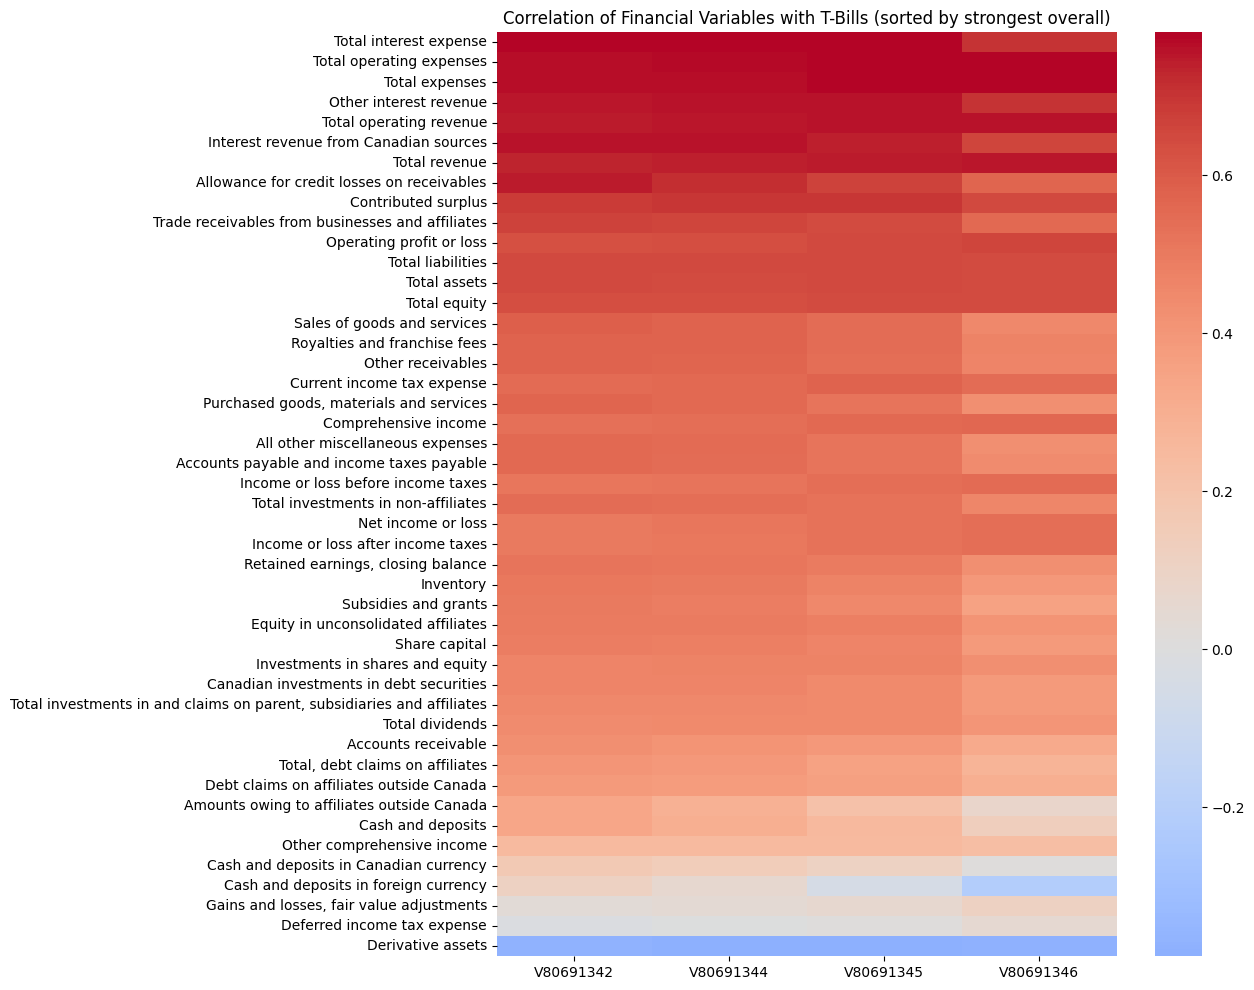

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sorted_corr = corr_results.reindex(corr_results.max(axis=1).sort_values(ascending=False).index)

plt.figure(figsize=(10, 12))
sns.heatmap(sorted_corr, cmap="coolwarm", center=0)
plt.title("Correlation of Financial Variables with T-Bills (sorted by strongest overall)")
plt.show()

In [ ]:
results_bond = {}

# Define the list of bond yield columns
bond_cols = ['CDN.AVG.1YTO3Y.AVG', 'CDN.AVG.3YTO5Y.AVG', 'CDN.AVG.5YTO10Y.AVG', 'CDN.AVG.OVER.10.AVG', 'BD.CDN.2YR.DQ.YLD', 'BD.CDN.3YR.DQ.YLD', 'BD.CDN.5YR.DQ.YLD', 'BD.CDN.7YR.DQ.YLD', 'BD.CDN.10YR.DQ.YLD', 'BD.CDN.LONG.DQ.YLD', 'BD.CDN.RRB.DQ.YLD']

for var_type, group in df_merged.groupby("Balance sheet and income statement components, selected financial ratios"):
    corr = group[["VALUE"] + bond_cols].corr()["VALUE"].drop("VALUE")
    results_bond[var_type] = corr

corr_results_bond = pd.DataFrame(results_bond).T

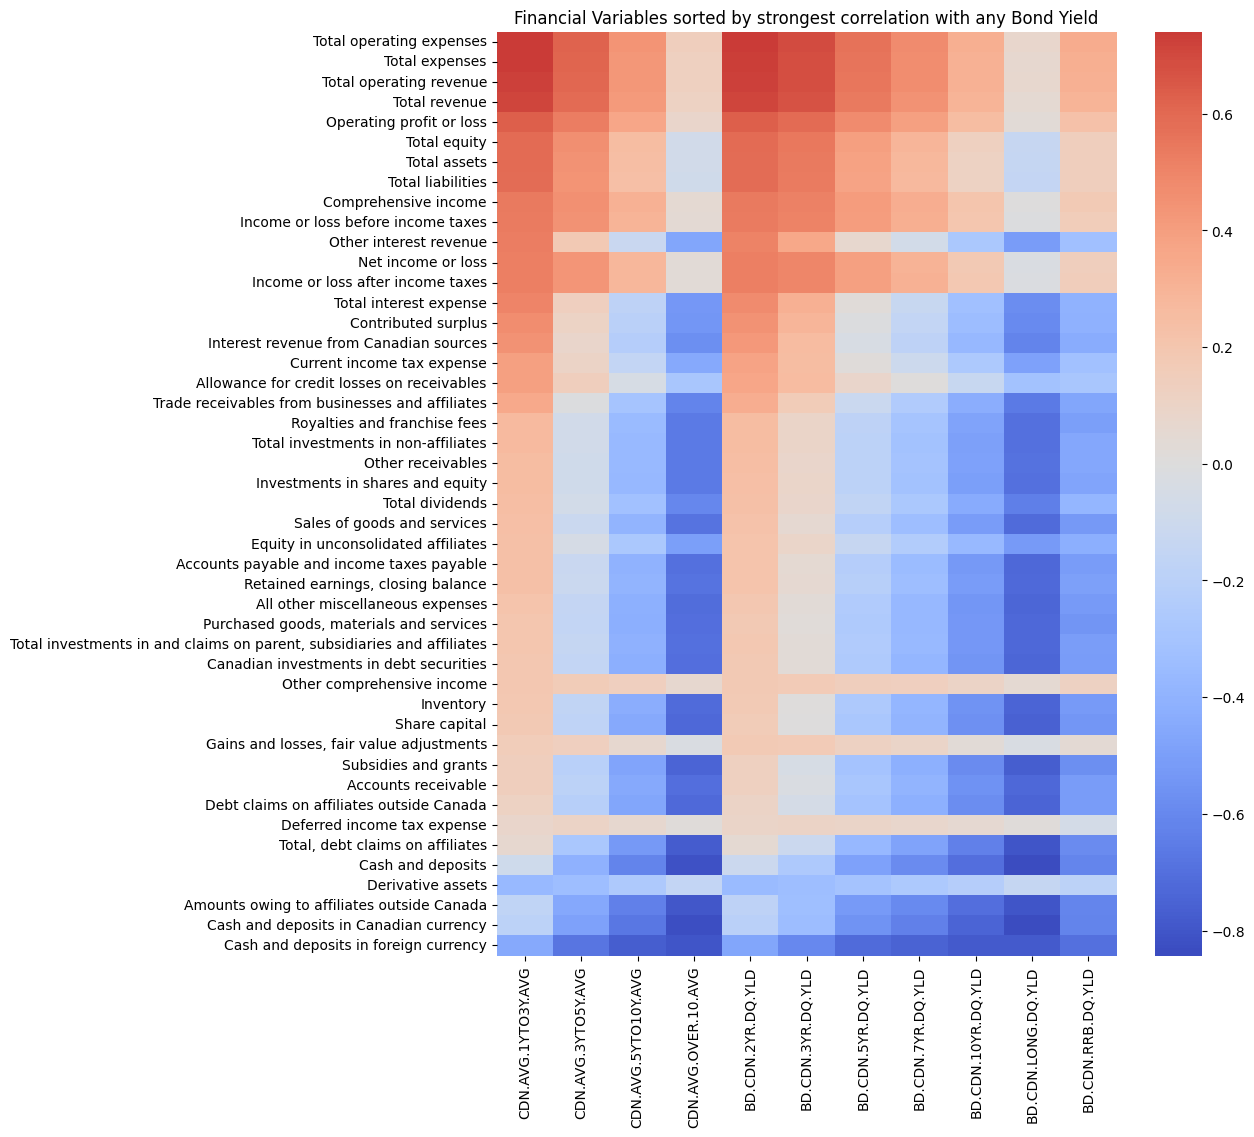

In [ ]:
sorted_corr_bond = corr_results_bond.reindex(
    corr_results_bond.max(axis=1).sort_values(ascending=False).index
)

plt.figure(figsize=(10, 12))
sns.heatmap(sorted_corr_bond, cmap="coolwarm", center=0)
plt.title("Financial Variables sorted by strongest correlation with any Bond Yield")
plt.show()

In [ ]:
corr_results.to_csv("corr_results_tbill.csv")

# Export Bond correlations
corr_results_bond.to_csv("corr_results_bond.csv")

In [ ]:
from google.colab import files
files.download("corr_results_tbill.csv")
files.download("corr_results_bond.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>